In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [2]:
!pip install wandb

In [3]:
!pip install -q faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 84.5 MB/s eta 0:00:00


In [4]:
!pip install -q langchain

In [5]:
!pip install -q langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.5/558.5 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
ydata-profiling 4.18.4 requires numpy<2.4,>=1.22, but you have numpy 2.4.6 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 

In [6]:
!pip install -q sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 92.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

In [7]:
!pip install transformers

In [8]:
!pip install -q langchain-huggingface

## imports

In [9]:
import wandb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset,DataLoader
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import TfidfVectorizer
import torch
import torch.nn as nn
from langchain_community.embeddings import HuggingFaceEmbeddings
import faiss
from langchain_community.vectorstores.utils import DistanceStrategy
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from transformers import BitsAndBytesConfig
from langchain_classic.chains import RetrievalQA
from sentence_transformers import SentenceTransformer, util
from tqdm.auto import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
from datasets import load_dataset
from transformers import AutoTokenizer,AutoModel,pipeline,T5ForConditionalGeneration, T5Tokenizer,AutoModelForMultipleChoice,AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType
from langchain_core.prompts import PromptTemplate
from langchain_huggingface import HuggingFacePipeline
from sklearn.metrics import accuracy_score, f1_score
import re
import random

/tmp/ipykernel_25/335420305.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import HuggingFaceEmbeddings


In [10]:
# wandb.login()

In [11]:
from kaggle_secrets import UserSecretsClient
import wandb
user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("WANDB_API_KEY")
wandb.login(key=api_key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

## wandb initilization and stuffs...

In [12]:
run = wandb.init(
    entity="dlgenai-t22026",
    project="dlgenai-t226",
    name="model1-dl-genai",
    config={"model": "TF-IDF + Cosine Similarity",
    "dataset": "Smart MCQ Solver",
    "task": "MCQ Answer Ranking",
    "metric": "MAP@3"
    }
)

wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260723_144916-bfnrl0s1
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run model1-dl-genai
wandb: ⭐️ View project at https://wandb.ai/dlgenai-t22026/dlgenai-t226
wandb: 🚀 View run at https://wandb.ai/dlgenai-t22026/dlgenai-t226/runs/bfnrl0s1


## loading data

In [13]:
sample=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

In [14]:
train_df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test_df=pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

## EDA

In [15]:
train_df.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [16]:
train_df.shape

(2000, 8)

### **the training data has 2000 rows and 8 columns**

In [17]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [18]:
train_df.describe()

,id
count,2000.000000
mean,1000.500000
std,577.494589
min,1.000000
25%,500.750000
50%,1000.500000
75%,1500.250000
max,2000.000000


### most of them are text so cant get much insight from descriptive stats

In [19]:
train_df.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

### **No missing values**

In [20]:
train_df["answer"].value_counts()

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

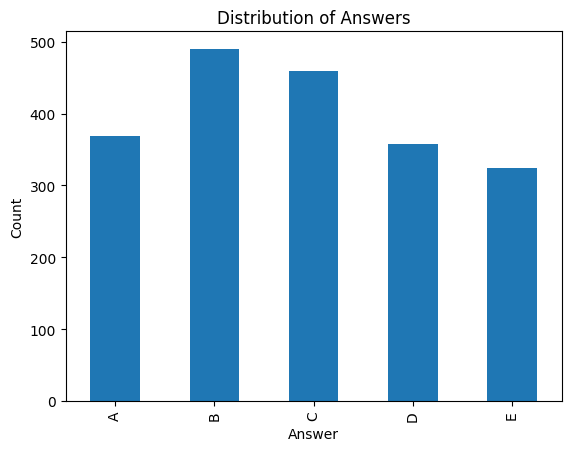

In [21]:
train_df["answer"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Answers")
plt.xlabel("Answer")
plt.ylabel("Count")
plt.show()

### **it has a little imbalance not much**

# DATA PREPROCESSING

## Data Split

In [22]:
train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["answer"])

### **we use stratify to keep the same answer distribution in both the training and validation datasets...for more reliable evaluation**

In [23]:
print(f"Training Samples   : {len(train_data)}")
print(f"Validation Samples : {len(val_data)}")

Training Samples   : 1600
Validation Samples : 400


# FEATURE ENGINEERING

In [24]:
def create_samples(df):
    texts = []
    labels = []
    options = ["A", "B", "C", "D", "E"]
    for _, row in df.iterrows():
        prompt = row["prompt"]
        for option in options:
            text = prompt + " " + str(row[option])
            texts.append(text)
            if option == row["answer"]:
                labels.append(1)
            else:
                labels.append(0)
    return texts, labels

In [25]:
train_texts, train_labels = create_samples(train_data)
val_texts, val_labels = create_samples(val_data)
print("Training Samples :", len(train_texts))
print("Validation Samples:", len(val_texts))

Training Samples : 8000
Validation Samples: 2000


## Convert Text into TF-IDF Features

In [26]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

In [27]:
X_train = vectorizer.fit_transform(train_texts)
X_val = vectorizer.transform(val_texts)

### **converted the text into numerical feature vectors**

### **pytorch works with tensors so we have to convert it first**

## PyTorch Data Pipeline

In [28]:
X_train_tensor = torch.tensor(X_train.toarray(), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.toarray(), dtype=torch.float32)

In [29]:
y_train_tensor = torch.tensor(train_labels, dtype=torch.float32)
y_val_tensor = torch.tensor(val_labels, dtype=torch.float32)

### **we have converted them to tensors ....these tensors will be used to train the neural network**

## TensorDataset

In [30]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

In [31]:
val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

In [32]:
BATCH_SIZE = 64
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [33]:

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [34]:
print("Training Batches :", len(train_loader))
print("Validation Batches:", len(val_loader))

Training Batches : 125
Validation Batches: 32


# MODEL 1

## Build the Neural Network

In [35]:
input_size = X_train_tensor.shape[1]
print("Input Size:", input_size)

Input Size: 10000


In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

Using Device: cuda


In [37]:
input_size = X_train_tensor.shape[1]

In [38]:
class MCQClassifier(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.network(x)

In [39]:
model = MCQClassifier(input_size).to(device)
print(model)

MCQClassifier(
  (network): Sequential(
    (0): Linear(in_features=10000, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [40]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# Model training

In [41]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

## validate

In [42]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(1)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item()
    return running_loss / len(loader)

## training loop

In [43]:
best_val_loss = float("inf")
EPOCHS = 20
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )
    val_loss = validate(
        model,
        val_loader,
        criterion,
        device
    )
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print(f"✅ Best model saved! Validation Loss: {val_loss:.4f}")
    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Validation Loss: {val_loss:.4f}"
    )
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "validation_loss": val_loss
    })

✅ Best model saved! Validation Loss: 0.3120
Epoch [1/20] | Train Loss: 0.4548 | Validation Loss: 0.3120
✅ Best model saved! Validation Loss: 0.1377
Epoch [2/20] | Train Loss: 0.2062 | Validation Loss: 0.1377
✅ Best model saved! Validation Loss: 0.0989
Epoch [3/20] | Train Loss: 0.1038 | Validation Loss: 0.0989
✅ Best model saved! Validation Loss: 0.0686
Epoch [4/20] | Train Loss: 0.0717 | Validation Loss: 0.0686
✅ Best model saved! Validation Loss: 0.0615
Epoch [5/20] | Train Loss: 0.0579 | Validation Loss: 0.0615
Epoch [6/20] | Train Loss: 0.0499 | Validation Loss: 0.0628
✅ Best model saved! Validation Loss: 0.0521
Epoch [7/20] | Train Loss: 0.0442 | Validation Loss: 0.0521
Epoch [8/20] | Train Loss: 0.0409 | Validation Loss: 0.0529
✅ Best model saved! Validation Loss: 0.0466
Epoch [9/20] | Train Loss: 0.0384 | Validation Loss: 0.0466
✅ Best model saved! Validation Loss: 0.0464
Epoch [10/20] | Train Loss: 0.0338 | Validation Loss: 0.0464
✅ Best model saved! Validation Loss: 0.0456
Epo

## Model Evaluation

In [44]:
model.eval()
predictions = []
with torch.no_grad():
    for X_batch, _ in val_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        scores = torch.sigmoid(outputs)
        predictions.extend(scores.squeeze().cpu().numpy())

In [45]:
option_names = ["A", "B", "C", "D", "E"]
predicted_answers = []
for i in range(0, len(predictions), 5):
    scores = predictions[i:i+5]
    ranked = sorted(
        zip(option_names, scores),
        key=lambda x: x[1],
        reverse=True
    )
    top3 = [option for option, _ in ranked[:3]]
    predicted_answers.append(top3)

In [46]:
true_answers = val_data["answer"].tolist()

In [47]:
def apk(actual, predicted, k=3):
    if actual in predicted[:k]:
        return 1 / (predicted.index(actual) + 1)
    return 0
def mapk(actuals, predictions, k=3):
    scores = []
    for actual, predicted in zip(actuals, predictions):
        scores.append(apk(actual, predicted, k))
    return sum(scores) / len(scores)

In [48]:
map3_score = mapk(
    true_answers,
    predicted_answers
)
print(f"Validation MAP@3: {map3_score:.4f}")
wandb.log({
    "MAP@3": map3_score
})

Validation MAP@3: 0.9671


### i dont think 0.9671 is possible there must be some issue

In [49]:
for i in range(5):
    print(f"Question {i+1}")
    print("Actual:", true_answers[i])
    print("Predicted:", predicted_answers[i])
    print()

Question 1
Actual: C
Predicted: ['A', 'C', 'E']

Question 2
Actual: D
Predicted: ['D', 'A', 'C']

Question 3
Actual: E
Predicted: ['E', 'A', 'B']

Question 4
Actual: D
Predicted: ['D', 'E', 'B']

Question 5
Actual: D
Predicted: ['D', 'E', 'B']



In [50]:
correct_top1 = 0
for actual, pred in zip(true_answers, predicted_answers):
    if actual == pred[0]:
        correct_top1 += 1
print(correct_top1)
print(len(true_answers))
print(correct_top1 / len(true_answers))

379
400
0.9475


In [51]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
print("Model saved successfully!")

Model saved successfully!


### **Tried multiple things but my scored seems to be stuck at 0.74854 maybe i should move on to the second model now....i tried with different learning rates but my scores started dropping slightly so i conclude this is what i can do with this architecture**

## Submit

In [52]:
test_texts = []
for _, row in test_df.iterrows():
    prompt = row["prompt"]
    for option in ["A", "B", "C", "D", "E"]:
        text = prompt + " " + str(row[option])
        test_texts.append(text)

In [53]:
X_test = vectorizer.transform(test_texts)

In [54]:
X_test_tensor = torch.tensor(
    X_test.toarray(),
    dtype=torch.float32
)
test_dataset = TensorDataset(X_test_tensor)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [55]:
model.eval()
test_scores = []
with torch.no_grad():
    for (X_batch,) in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        scores = torch.sigmoid(outputs)
        test_scores.extend(scores.squeeze().cpu().numpy())

In [56]:
option_names = ["A", "B", "C", "D", "E"]
predictions = []
for i in range(0, len(test_scores), 5):
    scores = test_scores[i:i+5]
    ranked = sorted(
        zip(option_names, scores),
        key=lambda x: x[1],
        reverse=True
    )
    top3 = " ".join([option for option, _ in ranked[:3]])
    predictions.append(top3)

In [57]:
# submission = test_df[["id"]].copy()
# submission["prediction"] = predictions
# submission.head()

In [58]:
# submission.to_csv("submission_model1.csv", index=False)
# print("Submission file saved successfully!")

In [59]:
kaggle_score = 0.74854
wandb.log({
    "kaggle_public_score": kaggle_score
})

# MODEL 2 - RAG

In [60]:
run = wandb.init(
    entity="dlgenai-t22026",
    project="dlgenai-t226",
    name="model2-langchain-rag-v1",
    config={
        "model": "Vanilla RAG",
        "embedding_model": "all-MiniLM-L6-v2",
        "vector_store": "FAISS",
        "top_k": 5,
        "framework": "LangChain"
    }
)

wandb: Finishing previous runs because reinit is set to 'default'.
wandb: updating run metadata
wandb: uploading history steps 15-21, summary, console lines 60-91
wandb: 
wandb: Run history:
wandb:               MAP@3 ▁
wandb:               epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb: kaggle_public_score ▁
wandb:          train_loss █▄▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:     validation_loss █▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:               MAP@3 0.96708
wandb:               epoch 20
wandb: kaggle_public_score 0.74854
wandb:          train_loss 0.02988
wandb:     validation_loss 0.04162
wandb: 
wandb: 🚀 View run model1-dl-genai at: https://wandb.ai/dlgenai-t22026/dlgenai-t226/runs/bfnrl0s1
wandb: ⭐️ View project at: https://wandb.ai/dlgenai-t22026/dlgenai-t226
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260723_144916-bfnrl0s1/logs
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /k

## LangChain Documents

In [61]:
documents = []
for _, row in train_df.iterrows():
    text = f"""
Question:
{row['prompt']}
Option A:
{row['A']}
Option B:
{row['B']}
Option C:
{row['C']}
Option D:
{row['D']}
Option E:
{row['E']}
"""
    doc = Document(
        page_content=text,
        metadata={
            "answer": row["answer"]
        }
    )

    documents.append(doc)

In [62]:
print("Total Documents:", len(documents))

Total Documents: 2000


In [63]:
print(documents[0])

page_content='
Question:
Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
Option A:
Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.
Option B:
Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.
Option C:
Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is solely based on the present.
Option D:
Ma

## Initialize the Embedding Model

In [64]:
embedding_model = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5",
    model_kwargs={'device': 'cuda'}
)

/tmp/ipykernel_25/1716439681.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## FAISS Vector Store

In [65]:
vector_store = FAISS.from_documents(
    documents=documents,
    embedding=embedding_model,
    distance_strategy=DistanceStrategy.COSINE
)

In [66]:
print(vector_store)

In [67]:
faiss_index = vector_store.index
print("Total vectors:", faiss_index.ntotal)

Total vectors: 2000


# Setting up the LLM

In [68]:
QWEN_MODEL="Qwen/Qwen2.5-7B-Instruct"

In [69]:
qwen_tokenizer = AutoTokenizer.from_pretrained(QWEN_MODEL)

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [70]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

In [71]:
qwen_model = AutoModelForCausalLM.from_pretrained(
    QWEN_MODEL,
    torch_dtype=torch.float16,
    device_map="auto"
)

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

In [72]:
text_generation_pipeline = pipeline(
    "text-generation",
    model=qwen_model,
    tokenizer=qwen_tokenizer,
    do_sample=False,
    max_new_tokens=8,
    return_full_text=False,
)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


In [73]:
llm = HuggingFacePipeline(
    pipeline=text_generation_pipeline
)

# Retrieval and Prompt template

In [74]:
retriever = vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}
)

In [75]:
print(retriever)

tags=['FAISS', 'HuggingFaceEmbeddings'] vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x7dbc06b73890> search_kwargs={'k': 3}


In [76]:
prompt_template = PromptTemplate.from_template("""
You are an expert at solving multiple-choice questions.
Use the retrieved context as supporting information.
If the context is not sufficient, answer by reasoning from the question and the options.
Context:
{context}
Question:
{question}
A. {A}
B. {B}
C. {C}
D. {D}
E. {E}
Return exactly THREE unique option letters in ranked order.
Format:
B D A
Do not explain your answer.
""")

In [77]:
def retrieve_context(question):
    docs = retriever.invoke(question)
    context = "\n\n".join(
        doc.page_content
        for doc in docs
    )
    return context

In [78]:
def build_prompt(row):
    context = retrieve_context(row["prompt"])
    prompt = prompt_template.format(
        context=context,
        question=row["prompt"],
        A=row["A"],
        B=row["B"],
        C=row["C"],
        D=row["D"],
        E=row["E"]
    )
    return prompt

## Generate Answer

In [79]:
def extract_answers(text):
    matches = re.findall(r"\b[A-E]\b", text)
    preds = []
    for m in matches:
        if m not in preds:
            preds.append(m)
        if len(preds) == 3:
            break
    while len(preds) < 3:
        for x in ["A","B","C","D","E"]:
            if x not in preds:
                preds.append(x)
            if len(preds) == 3:
                break
    return preds

In [80]:
def predict_answer(row):
    prompt = build_prompt(row)
    response = llm.invoke(prompt)
    return extract_answers(response)

In [81]:
!nvidia-smi

Thu Jul 23 14:52:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   61C    P0             30W /   70W |    8049MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [82]:
from tqdm.auto import tqdm
val_predictions = []
for _, row in tqdm(val_data.iterrows(), total=len(val_data)):
    prediction = predict_answer(row)
    val_predictions.append(prediction)

  0%|          | 0/400 [00:00<?, ?it/s]

Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_ne

In [83]:
val_results = val_data.copy()
val_results["prediction"] = val_predictions
val_results.head()

,id,prompt,A,B,C,D,E,answer,prediction
1283,1284,What is a phageome?,A community of viruses and their metagenomes l...,A community of bacteria and their metagenomes ...,A community of bacteriophages and their metage...,A community of fungi and their metagenomes loc...,A community of archaea and their metagenomes l...,C,"[C, E, A]"
87,88,Identify the correct statement: What is the ro...,CYCLOIDEA genes are responsible for the select...,CYCLOIDEA genes are responsible for the evolut...,CYCLOIDEA genes are responsible for the expres...,CYCLOIDEA genes are responsible for the expres...,CYCLOIDEA genes are responsible for mutations ...,D,"[B, D, A]"
1212,1213,Determine the correct option: What did Fresnel...,Fresnel predicted and verified that three tota...,Fresnel predicted and verified that eight tota...,Fresnel predicted and verified that four total...,Fresnel predicted and verified that two total ...,Fresnel predicted and verified that four total...,E,"[E, D, A]"
1665,1666,Pick the best possible answer: What is the mai...,"Environmental studies, with a main focus on ma...","Environmental studies, with a main focus on ma...","Environmental studies, with a main focus on ma...","Environmental studies, with a main focus on ma...","Environmental studies, with a main focus on sp...",D,"[D, C, A]"
1092,1093,What is the reason that Newton's second law ca...,"The existence of particle spin, which is linea...","The existence of particle spin, which is angul...","The existence of particle spin, which is linea...","The existence of particle spin, which is angul...","The existence of particle spin, which is angul...",D,"[D, A, B]"


In [84]:
top1_predictions = [
    preds[0] if isinstance(preds, list) else preds
    for preds in val_results["prediction"]
]

In [85]:
accuracy = accuracy_score(
    val_results["answer"],
    top1_predictions
)

In [86]:
f1 = f1_score(
    val_results["answer"],
    top1_predictions,
    average="macro"
)

In [87]:
print("Accuracy:", accuracy)
print("Macro F1:", f1)

Accuracy: 0.75
Macro F1: 0.7428092706052634


In [88]:
def apk(actual, predicted, k=3):
    if len(predicted) > k:
        predicted = predicted[:k]
    score = 0.0
    num_hits = 0.0
    for i, p in enumerate(predicted):
        if p in actual and p not in predicted[:i]:
            num_hits += 1.0
            score += num_hits / (i + 1.0)
    if len(actual) == 0:
        return 0.0
    return score / min(len(actual), k)
def mapk(actual, predicted, k=3):
    return sum(apk(a, p, k) for a, p in zip(actual, predicted)) / len(actual)

In [89]:
true = [[x] for x in val_results["answer"]]
pred = val_results["prediction"].tolist()
map3 = mapk(true, pred, k=3)
print("MAP@3:", map3)

MAP@3: 0.8275


In [90]:
wandb.log({
    "Accuracy": accuracy,
    "Macro_F1": f1,
    "MAP@3": map3
})

wandb.finish()

wandb: updating run metadata
wandb: uploading history steps 0-0, summary, console lines 451-459
wandb: 
wandb: Run history:
wandb: Accuracy ▁
wandb:    MAP@3 ▁
wandb: Macro_F1 ▁
wandb: 
wandb: Run summary:
wandb: Accuracy 0.75
wandb:    MAP@3 0.8275
wandb: Macro_F1 0.74281
wandb: 
wandb: 🚀 View run model2-langchain-rag-v1 at: https://wandb.ai/dlgenai-t22026/dlgenai-t226/runs/athym1pn
wandb: ⭐️ View project at: https://wandb.ai/dlgenai-t22026/dlgenai-t226
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260723_144938-athym1pn/logs


In [91]:
test_predictions = []
for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    test_predictions.append(predict_answer(row))

  0%|          | 0/500 [00:00<?, ?it/s]

Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_ne

In [92]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "prediction": [" ".join(pred) for pred in test_predictions]
})

In [93]:
submission.to_csv("submission.csv", index=False)

In [94]:
submission.head()

,id,prediction
0,1,A E D
1,2,B D A
2,3,B D E
3,4,E C A
4,5,C D A


# MILESTONE 1

### Q1)

In [95]:
# train_df["answer"].value_counts()

### Q2)

In [96]:
# cleaned=train_df["prompt"].str.lower()

In [97]:
# import string

In [98]:
# for char in string.punctuation:
#     cleaned=cleaned.str.replace(char,"",regex=False)

In [99]:
# len(cleaned.str.split().explode().unique())

### Q3)

In [100]:
# words = cleaned.iloc[1].split()
# filtered = [word for word in words if word not in ENGLISH_STOP_WORDS]
# len(filtered)

### Q4)

In [101]:
# combined = train_df[["prompt", "A", "B", "C", "D", "E"]].apply(lambda row: " ".join(row), axis=1)

In [102]:
# vectorizer = TfidfVectorizer(stop_words="english")
# vectorizer.fit_transform(combined)

In [103]:
# len(vectorizer.vocabulary_)

### Q5)

In [104]:
# prompt_vec = vectorizer.transform([train_df.loc[1, "prompt"]])
# option_a_vec = vectorizer.transform([train_df.loc[1, "A"]])

In [105]:
# score = cosine_similarity(prompt_vec, option_a_vec)
# round(float(score[0][0]), 4)

### Q6)

In [106]:
# correct = 0
# for idx, row in train_df.iterrows():
#     prompt_vec = vectorizer.transform([row["prompt"]])
#     scores = {}
#     for option in ["A", "B", "C", "D", "E"]:
#         option_vec = vectorizer.transform([row[option]])
#         scores[option] = cosine_similarity(prompt_vec, option_vec)[0][0]
#     best_option = max(scores, key=lambda x: scores[x])
#     if best_option == row["answer"]:
#         correct += 1

In [107]:
# percentage = round((correct / len(train_df)) * 100, 2)
# print(percentage)

### Q7)

In [108]:
# top3 = train_df["answer"].value_counts().index[:3].tolist()

In [109]:
# def apk(actual, predicted, k=3):
#     if actual in predicted[:k]:
#         return 1 / (predicted.index(actual) + 1)
#     return 0

In [110]:
# scores = train_df["answer"].apply(lambda x: apk(x, top3))
# map3 = round(scores.mean(), 4)
# print(map3)

### Q8)

In [111]:
# map3_scores = []

In [112]:
# for idx, row in train_df.iterrows():
#     prompt_vec = vectorizer.transform([row["prompt"]])
#     sim_scores = {}
#     for option in ["A", "B", "C", "D", "E"]:
#         option_vec = vectorizer.transform([row[option]])
#         sim_scores[option] = cosine_similarity(prompt_vec, option_vec)[0][0]
#     top3_preds = sorted(sim_scores, key=lambda x: sim_scores[x], reverse=True)[:3]
#     map3_scores.append(apk(row["answer"], top3_preds))

In [113]:
# print(round(sum(map3_scores) / len(map3_scores), 4))

# MILESTONE 2

### Q1)

In [114]:
# dataset = load_dataset("csv", data_files="/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")["train"]
# def combine(row):
#     return {"combined_text": row["prompt"] + " " + row["A"]}
# dataset = dataset.map(combine)
# print(len(dataset[51]["combined_text"]))

### Q2)

In [115]:
# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
# print(tokenizer.vocab_size)

### Q3)

In [116]:
# print(tokenizer.sep_token_id)

### Q4)

In [117]:
# prompts = list(dataset["prompt"])
# tokens = tokenizer(prompts, padding='max_length', truncation=True, max_length=128, return_tensors='pt')
# print(tokens["input_ids"].shape)

### Q5)

In [118]:
# model = AutoModel.from_pretrained("bert-base-uncased")
# prompt = dataset[0]["prompt"]
# tokens = tokenizer(prompt, return_tensors='pt')
# output = model(**tokens)
# print(output.last_hidden_state.shape)

### Q6)

In [119]:
# cls_embedding = output.last_hidden_state[0, 0, :]
# print(round(cls_embedding[:5].sum().item(), 4))

### Q7)

In [120]:
# model = AutoModel.from_pretrained("bert-base-uncased", output_attentions=True)
# text = "Light-ion fusion is a technique."
# tokens = tokenizer(text, return_tensors='pt')
# print(tokenizer.convert_ids_to_tokens(tokens['input_ids'][0]))
# output = model(**tokens)
# attentions = output.attentions[-1][0][0]
# token_list = tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])
# fusion_idx = token_list.index('fusion')
# print(round(attentions[0][fusion_idx].item(), 4))

### Q8)

In [121]:
# model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
# prompt = dataset[0]["prompt"]
# option_b = dataset[0]["B"]
# emb1 = model.encode(prompt)
# emb2 = model.encode(option_b)
# score = util.cos_sim(emb1, emb2)
# print(round(float(score), 4))

### Q9)

In [122]:
# st_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# options = ["A", "B", "C", "D", "E"]
# prompt_embs = st_model.encode(list(train_df["prompt"]), show_progress_bar=True)
# option_embs = {opt: st_model.encode(list(train_df[opt]), show_progress_bar=True) for opt in options}

# minilm_preds = []
# for i in range(len(train_df)):
#     scores = {}
#     for opt in options:
#         scores[opt] = float(util.cos_sim(prompt_embs[i], option_embs[opt][i]))
#     top3 = sorted(scores, key=lambda x: scores[x], reverse=True)[:3]
#     minilm_preds.append(top3)

# minilm_map3 = np.mean([apk(train_df.iloc[i]["answer"], minilm_preds[i]) for i in range(len(train_df))])
# print("MiniLM MAP@3:", round(minilm_map3, 4))

# train_df["combined"] = train_df[["prompt","A","B","C","D","E"]].apply(lambda row: " ".join(row), axis=1)
# vec = TfidfVectorizer(stop_words="english")
# tfidf_preds = []
# for i in range(len(train_df)):
#     prompt_vec = vec.fit_transform([train_df.iloc[i]["prompt"]])
#     sim_scores = {}
#     for opt in options:
#         opt_vec = vec.transform([train_df.iloc[i][opt]])
#         sim_scores[opt] = cosine_similarity(prompt_vec, opt_vec)[0][0]
#     top3 = sorted(sim_scores, key=lambda x: sim_scores[x], reverse=True)[:3]
#     tfidf_preds.append(top3)
# count = 0
# for i in range(len(train_df)):
#     answer = train_df.iloc[i]["answer"]
#     if answer not in tfidf_preds[i] and answer in minilm_preds[i]:
#         count += 1
# print("MiniLM wins over TF-IDF count:", count)

### Q10)

In [123]:
# classifier = pipeline("zero-shot-classification")
# prompt = dataset[1]["prompt"]
# candidate_labels = [dataset[1]["A"], dataset[1]["B"], dataset[1]["C"]]
# result = classifier(prompt, candidate_labels)
# print(round(result["scores"][0], 4))

### Q11)

In [124]:
# result_single = classifier(prompt, candidate_labels)
# result_multi = classifier(prompt, candidate_labels, multi_label=True)
# sum_single = sum(result_single["scores"])
# sum_multi = sum(result_multi["scores"])
# print(round(abs(sum_single - sum_multi), 4))

### Q12)

In [125]:
# tokenizer_flan = T5Tokenizer.from_pretrained("google/flan-t5-small")
# model_flan = T5ForConditionalGeneration.from_pretrained("google/flan-t5-small")
# prompt_text = dataset[0]["prompt"]
# option_a = dataset[0]["A"]
# option_b = dataset[0]["B"]
# input_text = f"Question: {prompt_text}. Is the correct answer A: {option_a} or B: {option_b}? Answer with just the letter A or B."
# inputs = tokenizer_flan(input_text, return_tensors="pt")
# outputs = model_flan.generate(**inputs, max_new_tokens=5)
# print(tokenizer_flan.decode(outputs[0], skip_special_tokens=True))

# MILESTONE 3

### Q1)

In [126]:
# !pip install -q faiss-cpu

# import pandas as pd
# import numpy as np
# import faiss
# from sentence_transformers import SentenceTransformer, CrossEncoder
# from transformers import AutoTokenizer, pipeline
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.metrics.pairwise import cosine_similarity

# print("Creating knowledge base")
# kb = []
# for idx, row in train_df.iterrows():
#     correct_letter = row["answer"]
#     kb.append(str(row[correct_letter]))

# print("Loading embedding model and creating index")
# model = SentenceTransformer("all-MiniLM-L6-v2")
# kb_embeddings = model.encode(kb, show_progress_bar=False)

# index = faiss.IndexFlatL2(kb_embeddings.shape[1])
# index.add(kb_embeddings)

# print("Knowledge base successfully created")

# # Zero-shot classifier for Q1, Q2, Q6
# zs = pipeline(
#     "zero-shot-classification",
#     model="facebook/bart-large-mnli"
# )

# row_150 = train_df.iloc[150]
# prompt_150 = str(row_150["prompt"])
# labels_150 = [
#     str(row_150["A"]),
#     str(row_150["B"]),
#     str(row_150["C"]),
#     str(row_150["D"]),
#     str(row_150["E"])
# ]
# ans_150 = str(row_150[row_150["answer"]])

In [127]:
# result = zs(prompt_150, candidate_labels=labels_150)
# print(result)

In [128]:
# ground_truth_score = result["scores"][result["labels"].index(ans_150)]
# print(round(ground_truth_score, 3))

### Q2)

In [129]:
# query_embedding = model.encode([prompt_150], show_progress_bar=False)
# D, I = index.search(query_embedding, k=10)
# print("Retrieved KB indices:")
# print(I[0])
# print("\nRetrieved documents:")
# for rank, idx in enumerate(I[0], start=1):
#     print(f"Rank {rank}: KB index {idx}")
#     print(kb[idx][:120], "...\n")
# if 150 in I[0]:
#     rank = list(I[0]).index(150) + 1
#     print(f"True document found at Rank {rank}")
# else:
#     print("True document is NOT in the top 10.")

### Q3)

In [130]:
# cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')
# retrieved_indices = I[0]
# docs_10 = [kb[i] for i in retrieved_indices]
# pairs = [[prompt_150, doc] for doc in docs_10]
# ce_scores = cross_encoder.predict(pairs)

In [131]:
# ranking = sorted(
#     zip(retrieved_indices, ce_scores),
#     key=lambda x: x[1],
#     reverse=True
# )
# for rank, (idx, score) in enumerate(ranking, start=1):
#     print(f"Rank {rank}: KB index {idx}, Score: {score:.4f}")
# for rank, (idx, score) in enumerate(ranking, start=1):
#     if idx == 150:
#         print(f"\nTrue document found at Rank {rank}")
#         break

### Q4)

In [132]:
# row_42 = train_df.iloc[42]
# prompt_42 = str(row_42["prompt"])
# query_embedding = model.encode([prompt_42], show_progress_bar=False)
# D, I = index.search(query_embedding, k=5)
# docs_5 = [kb[i] for i in I[0]]
# concatenated_docs = " ".join(docs_5)
# text = f"Context: {concatenated_docs} Question: {prompt_42}"
# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
# tokens = tokenizer(text, truncation=False)
# print("Total tokens:", len(tokens["input_ids"]))

### Q5)

In [133]:
# row_150 = train_df.iloc[150]
# prompt_150 = str(row_150["prompt"])
# true_document = kb[150]
# rag_prompt = f"Context: {true_document} Question: {prompt_150}"
# result_rag = zs(
#     rag_prompt,
#     candidate_labels=labels_150
# )
# print(result_rag)
# ground_truth_score = result_rag["scores"][result_rag["labels"].index(ans_150)]
# print("Ground-truth score:", round(ground_truth_score, 3))

### Q6)

In [134]:
# row_150 = train_df.iloc[150]
# prompt_150 = str(row_150["prompt"])
# wrong_document = kb[999]
# adversarial_prompt = f"Context: {wrong_document} Question: {prompt_150}"
# result_adv = zs(
#     adversarial_prompt,
#     candidate_labels=labels_150
# )
# print(result_adv)
# ground_truth_score = result_adv["scores"][result_adv["labels"].index(ans_150)]
# print("Ground-truth score:", round(ground_truth_score, 3))

### Q7)

In [135]:
# hits = 0
# for i in range(100):
#     prompt = str(train_df.iloc[i]["prompt"])
#     correct_option = train_df.iloc[i][train_df.iloc[i]["answer"]]
#     query_embedding = model.encode([prompt], show_progress_bar=False)
#     D, I = index.search(query_embedding, k=5)
#     retrieved_docs = [kb[idx] for idx in I[0]]
#     if any(correct_option == doc for doc in retrieved_docs):
#         hits += 1
# hit_rate = (hits / 100) * 100
# print("Hits:", hits)
# print("Hit Rate:", round(hit_rate, 1))

### Q8)

In [136]:
# def apk(actual, predicted, k=3):
#     if actual in predicted[:k]:
#         return 1 / (predicted.index(actual) + 1)
#     return 0
# scores = []
# for i in range(20):
#     row = train_df.iloc[i]
#     prompt = str(row["prompt"])
#     query_embedding = model.encode([prompt], show_progress_bar=False)
#     D, I = index.search(query_embedding, k=5)
#     retrieved_indices = I[0]
#     docs = [kb[idx] for idx in retrieved_indices]
#     pairs = [[prompt, doc] for doc in docs]
#     ce_scores = cross_encoder.predict(pairs)
#     best_doc = docs[np.argmax(ce_scores)]
#     rag_prompt = f"Context: {best_doc} Question: {prompt}"
#     labels = [
#         str(row["A"]),
#         str(row["B"]),
#         str(row["C"]),
#         str(row["D"]),
#         str(row["E"])
#     ]
#     result = zs(rag_prompt, candidate_labels=labels)
#     option_map = {
#         row["A"]: "A",
#         row["B"]: "B",
#         row["C"]: "C",
#         row["D"]: "D",
#         row["E"]: "E"
#     }
#     predicted_letters = [option_map[label] for label in result["labels"]]
#     scores.append(apk(row["answer"], predicted_letters))
# final_map3 = np.mean(scores)
# print("MAP@3:", round(final_map3, 3))

# MILESTONE 4

In [137]:
# label_map = {
#     "A": 0,
#     "B": 1,
#     "C": 2,
#     "D": 3,
#     "E": 4
# }

In [138]:
# train_df["label"] = train_df["answer"].map(label_map)
# print(train_df.loc[150, "label"])

In [139]:
# formatted = str(train_df.loc[0, "prompt"]) + " [SEP] " + str(train_df.loc[0, "B"])
# len(formatted)

In [140]:
# tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
# row = train_df.loc[0]

# choices = [
#     str(row["prompt"]) + " [SEP] " + str(row["A"]),
#     str(row["prompt"]) + " [SEP] " + str(row["B"]),
#     str(row["prompt"]) + " [SEP] " + str(row["C"]),
#     str(row["prompt"]) + " [SEP] " + str(row["D"]),
#     str(row["prompt"]) + " [SEP] " + str(row["E"]),
# ]

# enc = tokenizer(
#     choices,
#     padding="max_length",
#     truncation=True,
#     max_length=128,
#     return_tensors="pt"
# )

# input_ids = enc["input_ids"].unsqueeze(0)
# print(input_ids.shape)

In [141]:
# input_ids.shape

In [142]:
# input_ids.numel()

In [143]:
# model = AutoModelForMultipleChoice.from_pretrained("bert-base-uncased")

In [144]:
# lora_config = LoraConfig(
#     r=8,
#     lora_alpha=16,
#     target_modules=["query", "value"],
#     lora_dropout=0.1,
#     bias="none",
#     task_type=TaskType.SEQ_CLS
# )

In [145]:
# model = get_peft_model(model, lora_config)

In [146]:
# trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(trainable_params)

In [147]:
# row = train_df.loc[0]
# choices = [
#     f"{row['prompt']} [SEP] {row['A']}",
#     f"{row['prompt']} [SEP] {row['B']}",
#     f"{row['prompt']} [SEP] {row['C']}",
#     f"{row['prompt']} [SEP] {row['D']}",
#     f"{row['prompt']} [SEP] {row['E']}",
# ]
# enc = tokenizer(
#     choices,
#     padding="max_length",
#     truncation=True,
#     max_length=64,      # same as Q9
#     return_tensors="pt"
# )
# input_ids = enc["input_ids"].unsqueeze(0)
# attention_mask = enc["attention_mask"].unsqueeze(0)

In [148]:
# model.eval()
# with torch.no_grad():
#     outputs = model(
#         input_ids=input_ids,
#         attention_mask=attention_mask
#     )

In [149]:
# probs = torch.softmax(outputs.logits, dim=1)
# print(probs)